Dataset shape: (100, 16)

Column names in the dataset:
'Patient ID'
'Age'
'FSH (mIU/mL)                  [0.1-100]'
'LH (mIU/mL)         [6.5-101]'
'Glucose_Fasting (mg/dl)     [54-126]'
'Glucose_PP(mg/dl)    [90-700]'
'Insulin_Fasting (microU/mL)
[1-50]'
'Insulin_PP(microU/mL)   [1-100]'
'Prolactin(ng/ml)   [1-80]'
'Testosterone(ng/dl)    [5-150]'
'T3(nmol/l)     [0.1-7]'
'T4(nmol/l)    [40-200]'
'TSH(microU/ml)    [0.1-10]'
'Result '
'TOTAL'
'Unnamed: 15'

Cleaned column names:
['Patient ID', 'Age', 'FSH (mIU/mL)', 'LH (mIU/mL)', 'Glucose_Fasting (mg/dl)', 'Glucose_PP(mg/dl)', 'Insulin_Fasting (microU/mL)', 'Insulin_PP(microU/mL)', 'Prolactin(ng/ml)', 'Testosterone(ng/dl)', 'T3(nmol/l)', 'T4(nmol/l)', 'TSH(microU/ml)', 'Result', 'TOTAL', 'Unnamed: 15']

Missing values in each column:
Patient ID                      0
Age                             0
FSH (mIU/mL)                    0
LH (mIU/mL)                     0
Glucose_Fasting (mg/dl)         0
Glucose_PP(mg/dl)               0

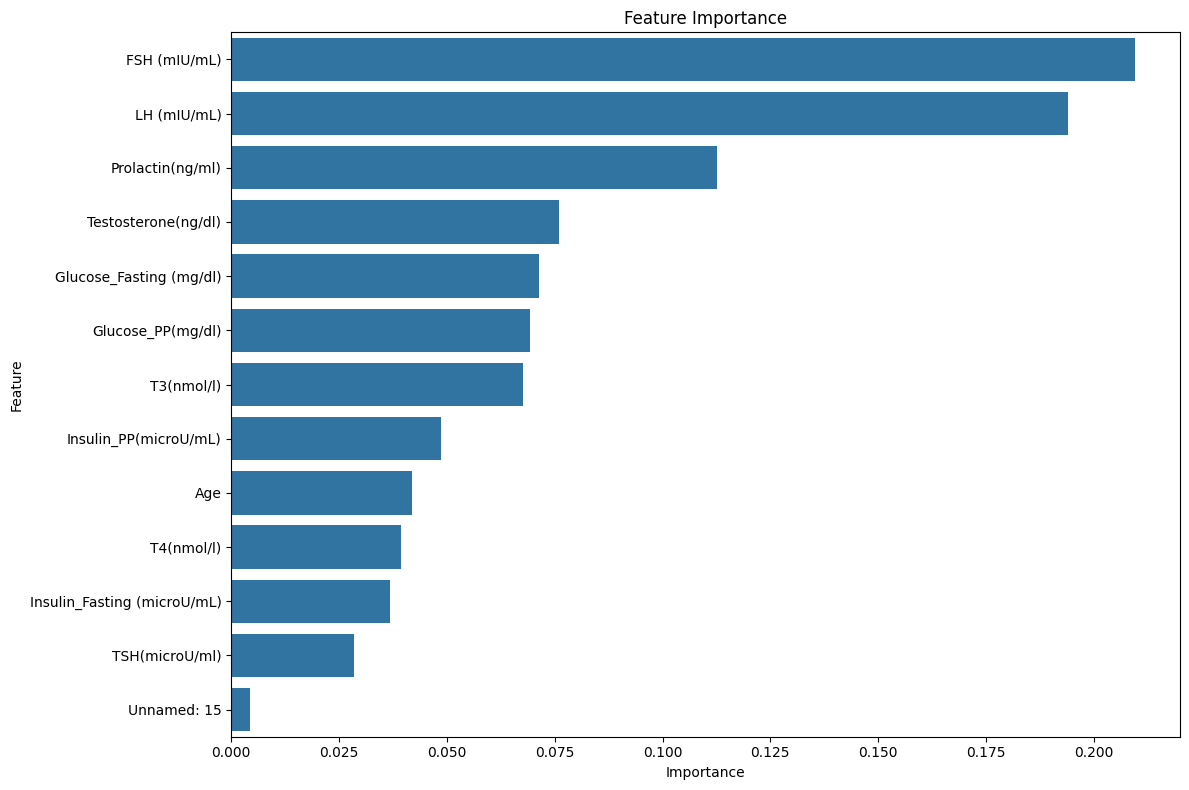

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
import pickle
import joblib

# Load the dataset
df = pd.read_csv('analysis.csv')

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumn names in the dataset:")
for col in df.columns:
    print(f"'{col}'")

# Clean column names - strip whitespace and remove brackets with ranges
cleaned_columns = []
for col in df.columns:
    # Split by the first '[' character and take the first part
    cleaned_col = col.split('[')[0].strip()
    cleaned_columns.append(cleaned_col)

df.columns = cleaned_columns
print("\nCleaned column names:")
print(df.columns.tolist())

# Handle missing values
# First, check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Impute missing values for numeric columns using median
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    imputer = SimpleImputer(strategy='median')
    df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# For categorical columns, fill with mode
categorical_cols = df.select_dtypes(exclude=[np.number]).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Process target variable
# Look for the result column with different possible names
result_column = None
for col in df.columns:
    if 'result' in col.lower():
        result_column = col
        break

if result_column is None:
    # If no column with 'result' in name, look for 'TOTAL' column
    if 'TOTAL' in df.columns:
        result_column = 'TOTAL'
    else:
        print("Could not find a target column (Result or TOTAL)")
        # Use the last column as target if we can't find a specific one
        result_column = df.columns[-1]
        print(f"Using '{result_column}' as the target variable")

# Set the target variable
df['Target'] = df[result_column]

# Drop rows with missing target values as we can't train on them
df = df.dropna(subset=['Target'])

# Encode the target variable
label_encoder = LabelEncoder()
df['Target_Encoded'] = label_encoder.fit_transform(df['Target'])
print("\nTarget classes:", label_encoder.classes_)
print("Encoded values:", list(range(len(label_encoder.classes_))))

# Select features for modeling
# Create a list of columns to drop
cols_to_drop = ['Patient ID', 'Target', 'Target_Encoded']
# Add result_column if it's not already in the list
if result_column not in cols_to_drop:
    cols_to_drop.append(result_column)
# Add 'TOTAL' if it exists and isn't already in the list
if 'TOTAL' in df.columns and 'TOTAL' not in cols_to_drop:
    cols_to_drop.append('TOTAL')

# Drop non-feature columns, but ignore any that don't exist
features = df.drop([col for col in cols_to_drop if col in df.columns], axis=1)

print("\nFeatures being used:")
print(features.columns.tolist())

# Convert any remaining string columns to numeric if possible
for col in features.columns:
    if features[col].dtype == 'object':
        try:
            features[col] = pd.to_numeric(features[col])
        except:
            print(f"Could not convert column {col} to numeric")
            # If conversion fails, one-hot encode the categorical variable
            features = pd.get_dummies(features, columns=[col], drop_first=True)

# Scale the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Check if we have enough data for a meaningful split
if len(df) > 10:
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        features_scaled,
        df['Target_Encoded'],
        test_size=0.25,
        random_state=42,
        stratify=df['Target_Encoded'] if len(df) > 10 else None
    )
else:
    # For very small datasets, use all data for both training and testing
    print("\nWARNING: Dataset is very small. Using all data for both training and evaluation.")
    X_train = X_test = features_scaled
    y_train = y_test = df['Target_Encoded']

# Train a Random Forest model
# First, let's do a quick hyperparameter tuning
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 3, 5]
}

# If the dataset is very small, use a simpler model
if len(df) < 20:
    print("\nSmall dataset detected. Using a simpler Random Forest model.")
    rf = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42)
    rf.fit(X_train, y_train)
else:
    # Use GridSearchCV for larger datasets
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=min(5, len(df) // 3) if len(df) >= 15 else 2,  # Adjust CV based on dataset size
        scoring='accuracy'
    )
    grid_search.fit(X_train, y_train)

    # Get the best model
    rf = grid_search.best_estimator_
    print("\nBest parameters:", grid_search.best_params_)

# Evaluate the model
y_pred = rf.predict(X_test)

print("\nModel Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
try:
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))
except:
    print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.close()

# Feature importance
feature_importances = pd.DataFrame({
    'Feature': features.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importances)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')

# ==== SAVE THE MODEL AND PREPROCESSING COMPONENTS ====

# Create a dictionary with all the components needed for prediction
model_components = {
    'model': rf,
    'scaler': scaler,
    'label_encoder': label_encoder,
    'feature_columns': features.columns.tolist(),
    'target_classes': label_encoder.classes_.tolist()
}

# Save the model components using pickle
with open('pcod_model.pkl', 'wb') as file:
    pickle.dump(model_components, file)

print("\nModel saved as 'pcod_model.pkl'")

# Alternative: Save using joblib (often better for sklearn objects)
joblib.dump(model_components, 'pcod_model_joblib.pkl')
print("Model also saved as 'pcod_model_joblib.pkl'")

# ==== CODE TO LOAD THE MODEL AND MAKE PREDICTIONS ====

print("\n\n==== DEMONSTRATING MODEL LOADING AND PREDICTION ====")

# Load the model using pickle
with open('pcod_model.pkl', 'rb') as file:
    loaded_components = pickle.load(file)

# Extract components
loaded_model = loaded_components['model']
loaded_scaler = loaded_components['scaler']
loaded_label_encoder = loaded_components['label_encoder']
feature_cols = loaded_components['feature_columns']
target_classes = loaded_components['target_classes']

print("Model loaded successfully!")
print(f"Target classes: {target_classes}")

# Function to make predictions on new data
def predict_pcod(new_data):
    """
    Make predictions using the loaded model

    Parameters:
    new_data (pd.DataFrame): DataFrame containing the same features used during training

    Returns:
    tuple: Predicted class label and probability
    """
    # Ensure the data has the right columns in the right order
    # Only select the columns that were used for training
    features_to_use = [col for col in feature_cols if col in new_data.columns]

    # Notify about any missing columns
    missing_cols = set(feature_cols) - set(features_to_use)
    if missing_cols:
        print(f"Warning: The following columns are missing: {missing_cols}")

    prepared_data = new_data[features_to_use]

    # Scale the features
    scaled_data = loaded_scaler.transform(prepared_data)

    # Make prediction
    pred_encoded = loaded_model.predict(scaled_data)
    pred_proba = loaded_model.predict_proba(scaled_data)

    # Convert encoded prediction back to original class label
    predictions = [target_classes[i] for i in pred_encoded]

    return predictions, pred_proba

# Test with a sample from the dataset
sample = df.iloc[0:1].copy()  # Get the first row as a sample
print("\nSample data:")
print(sample[feature_cols])

# Make prediction
predictions, probabilities = predict_pcod(sample[feature_cols])
print("\nPredicted class:", predictions[0])
print("Prediction probabilities:")
for i, class_name in enumerate(target_classes):
    print(f"{class_name}: {probabilities[0][i]:.4f}")

# Example of how to use the model for completely new data
print("\nExample of using the model with new data:")
print("To use this model with new data, create a DataFrame with the same features:")

# Create an example of new data (this is just for demonstration)
print("Example code for prediction:")
print("""
# Sample new data
new_patient = pd.DataFrame({
    'Age': [25],
    'FSH': [12.5],
    'LH': [18.3],
    'Glucose_Fasting': [100],
    'Glucose_PP': [180],
    'Insulin_Fasting': [15],
    'Insulin_PP': [25],
    'Prolactin': [30],
    'Testosterone': [20],
    'T3': [2.0],
    'T4': [60],
    'TSH': [4.5]
})

# Make prediction
predictions, probabilities = predict_pcod(new_patient)
print("Predicted class:", predictions[0])
""")